# Laboratorio 5: Análisis exploratorio de datos (EDA)

Se utiliza `train_clean.csv`, generado en el notebook 01.

**Este notebook cubre:**
- Punto 5: EDA completo — distribución de clases, análisis de keywords, longitud de tweets, palabras más repetidas por categoría, nube de palabras, histogramas, y discusión de palabras presentes en ambas categorías.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carga del dataset preprocesado

In [2]:
df = pd.read_csv("./data/train_clean.csv")
df["clean_text"] = df["clean_text"].fillna("")

df_desastre = df[df["target"] == 1]
df_no_desastre = df[df["target"] == 0]

print(f"Total de tweets: {len(df):,}")
print(f"Desastre real (1): {len(df_desastre):,}")
print(f"No desastre   (0): {len(df_no_desastre):,}")

Total de tweets: 7,613
Desastre real (1): 3,271
No desastre   (0): 4,342


## 2. Distribución de la variable objetivo (Punto 5)

Revisamos el balance de clases, algo fundamental antes de entrenar cualquier modelo.

In [3]:
conteo_target = df["target"].value_counts().sort_index()
prop_target = df["target"].value_counts(normalize=True).sort_index() * 100

resumen_target = pd.DataFrame({
    "clase": ["0 = No desastre", "1 = Sí desastre"],
    "n_tweets": conteo_target.values,
    "% del total": prop_target.round(2).values
})
resumen_target

,clase,n_tweets,% del total
0,0 = No desastre,4342,57.03
1,1 = Sí desastre,3271,42.97


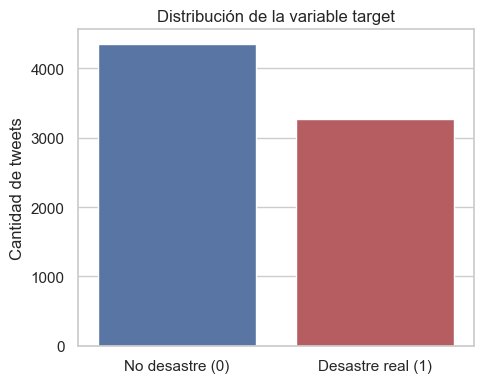

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="target", hue="target", palette=["#4C72B0", "#C44E52"], legend=False)
plt.xticks([0, 1], ["No desastre (0)", "Desastre real (1)"])
plt.title("Distribución de la variable target")
plt.ylabel("Cantidad de tweets")
plt.xlabel("")
plt.tight_layout()
plt.show()

**Análisis:** El dataset está moderadamente desbalanceado: aproximadamente 57% de los tweets no hablan de un desastre real y 43% sí. No es un desbalance extremo, por lo que conviene reportar métricas como precision, recall y F1 además de accuracy al evaluar los modelos.

## 3. Análisis de la columna `keyword` (Punto 5)

`keyword` es una palabra clave asociada al tweet extraída por Twitter. Se revisa cuáles se asocian más con tweets de desastre real vs. no real.

In [5]:
print("Keywords distintas:", df["keyword"].nunique())
print("Tweets sin keyword:", df["keyword"].isnull().sum())

top_keywords = df["keyword"].value_counts().head(15)
top_keywords

Keywords distintas: 221
Tweets sin keyword: 61


keyword
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
fear           40
outbreak       40
siren          40
twister        40
windstorm      40
collision      39
Name: count, dtype: int64

In [6]:
# Keywords con mayor proporción de tweets etiquetados como desastre real (target=1)
keyword_target = (
    df.dropna(subset=["keyword"])
      .groupby("keyword")["target"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "proporcion_desastre", "count": "n_tweets"})
)

print("Top 10 keywords más asociadas a desastre real:")
display(keyword_target[keyword_target["n_tweets"] >= 10].sort_values("proporcion_desastre", ascending=False).head(10))

print("\nTop 10 keywords menos asociadas a desastre real:")
display(keyword_target[keyword_target["n_tweets"] >= 10].sort_values("proporcion_desastre", ascending=True).head(10))

Top 10 keywords más asociadas a desastre real:


,proporcion_desastre,n_tweets
keyword,,
debris,1.000000,37
derailment,1.000000,39
wreckage,1.000000,39
outbreak,0.975000,40
oil%20spill,0.973684,38
typhoon,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29



Top 10 keywords menos asociadas a desastre real:


,proporcion_desastre,n_tweets
keyword,,
aftershock,0.000000,34
body%20bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body%20bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


**Análisis:** Hay keywords casi perfectamente predictivas como `debris`, `wreckage` y `derailment` (casi siempre desastre real), y otras como `body%20bag` o `ruin` que en Twitter se usan frecuentemente en sentido figurado. Esto sugiere que `keyword` podría ser una variable predictiva útil para el modelo.

## 4. Análisis de la longitud de los tweets (Punto 5)

Se compara la longitud de los tweets entre las dos clases para ver si existe una diferencia estructural.

In [7]:
df.groupby("target")[["n_caracteres", "n_palabras"]].describe().T

target                        0            1
n_caracteres count  4342.000000  3271.000000
             mean     95.832105   108.236319
             std      35.969652    29.369513
             min       7.000000    14.000000
             25%      68.000000    88.000000
             50%     101.000000   115.000000
             75%     130.000000   136.000000
             max     157.000000   151.000000
n_palabras   count  4342.000000  3271.000000
             mean     14.704744    15.167533
             std       6.161564     5.096806
             min       1.000000     2.000000
             25%      10.000000    11.000000
             50%      15.000000    15.000000
             75%      19.000000    19.000000
             max      31.000000    30.000000

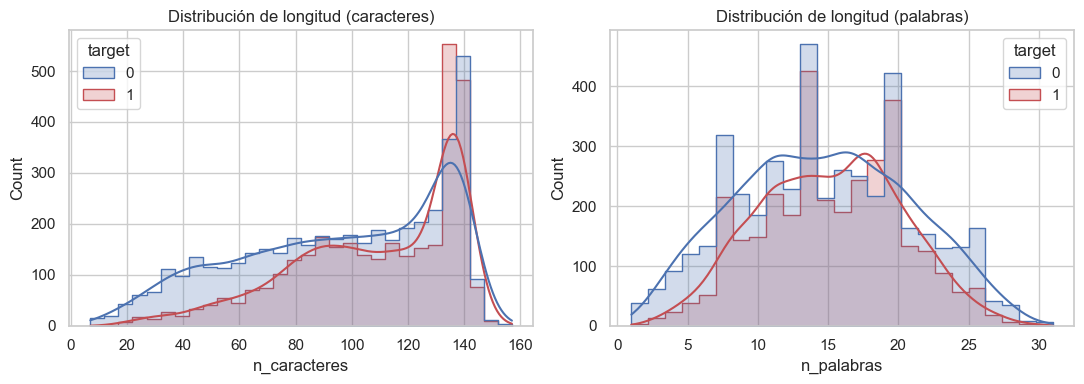

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=df, x="n_caracteres", hue="target", bins=30, kde=True, ax=axes[0],
             palette=["#4C72B0", "#C44E52"], element="step")
axes[0].set_title("Distribución de longitud (caracteres)")

sns.histplot(data=df, x="n_palabras", hue="target", bins=25, kde=True, ax=axes[1],
             palette=["#4C72B0", "#C44E52"], element="step")
axes[1].set_title("Distribución de longitud (palabras)")

plt.tight_layout()
plt.show()

**Análisis:** Las distribuciones de longitud son similares entre ambas clases, con una leve tendencia de los tweets de desastre real a ser un poco más largos. No es una diferencia relevante, así que la longitud por sí sola no es una variable fuertemente discriminante.

## 5. Palabra más repetida por categoría (Punto 5.1)

Se investiga qué palabra se repite más en cada una de las categorías.

In [9]:
def top_palabras(textos, n=20):
    contador = Counter()
    for t in textos:
        contador.update(t.split())
    return contador.most_common(n)


top_desastre = top_palabras(df_desastre["clean_text"], n=20)
top_no_desastre = top_palabras(df_no_desastre["clean_text"], n=20)

print("Palabra más repetida en 'Desastre real':", top_desastre[0])
print("Palabra más repetida en 'No desastre'  :", top_no_desastre[0])

Palabra más repetida en 'Desastre real': ('fire', 182)
Palabra más repetida en 'No desastre'  : ('like', 254)


## 6. Histograma de palabras más repetidas (Punto 5.1)

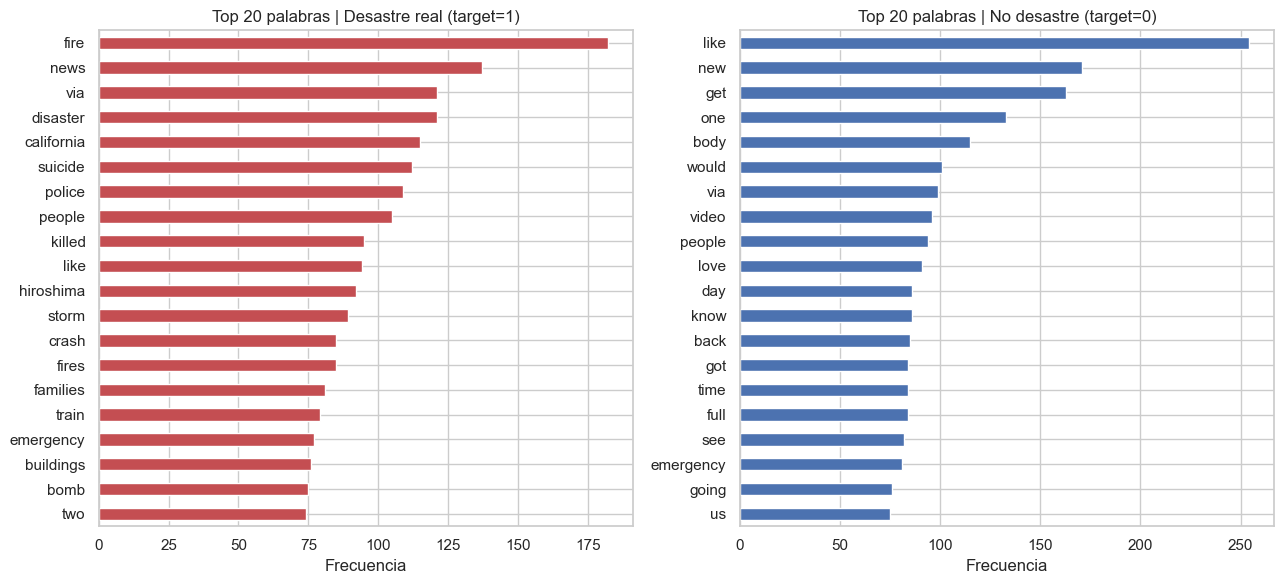

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

pd.Series(dict(top_desastre)).sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Top 20 palabras | Desastre real (target=1)")
axes[0].set_xlabel("Frecuencia")

pd.Series(dict(top_no_desastre)).sort_values().plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top 20 palabras | No desastre (target=0)")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

## 7. Nube de palabras por clase (Punto 5.1)

La nube de palabras permite visualizar visualmente los términos más frecuentes: el tamaño de cada palabra es proporcional a su frecuencia en el corpus.

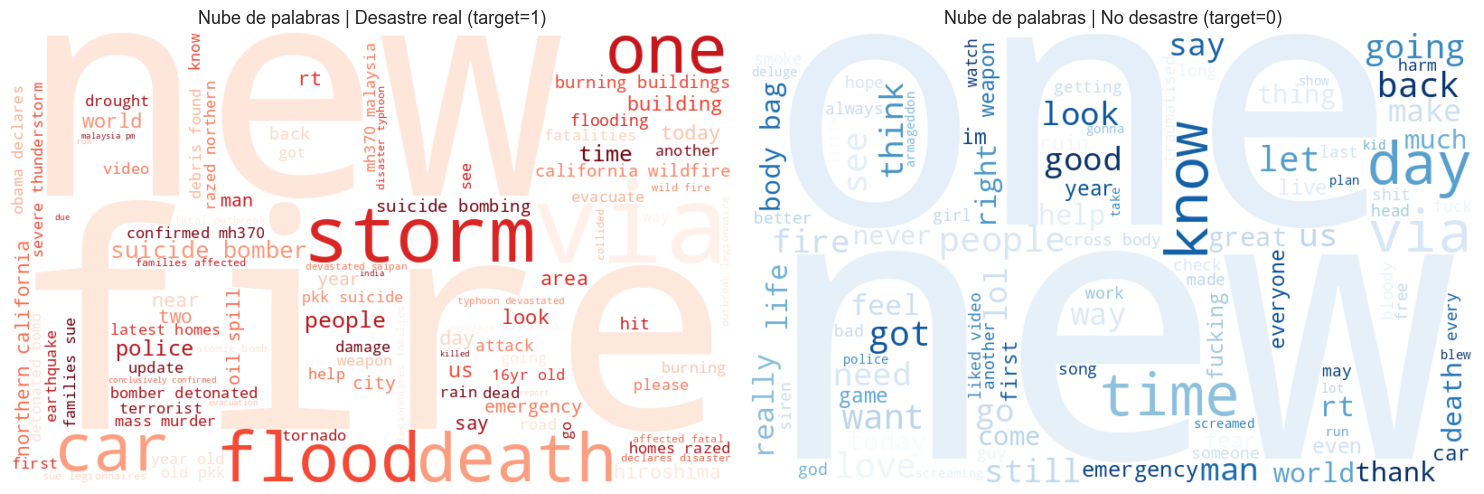

In [11]:
texto_desastre = " ".join(df_desastre["clean_text"])
texto_no_desastre = " ".join(df_no_desastre["clean_text"])

wc_desastre = WordCloud(width=800, height=500, background_color="white",
                         colormap="Reds", max_words=100,
                         random_state=RANDOM_STATE).generate(texto_desastre)

wc_no_desastre = WordCloud(width=800, height=500, background_color="white",
                            colormap="Blues", max_words=100,
                            random_state=RANDOM_STATE).generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(wc_desastre, interpolation="bilinear")
axes[0].set_title("Nube de palabras | Desastre real (target=1)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(wc_no_desastre, interpolation="bilinear")
axes[1].set_title("Nube de palabras | No desastre (target=0)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Interpretación:** la nube de *desastre real* confirma visualmente el dominio de vocabulario relacionado con emergencias concretas (incendios, tormentas, accidentes, ataques). La nube de *no desastre* mezcla vocabulario cotidiano y de entretenimiento.

## 8. Palabras presentes en ambas categorías (Punto 5.1)

Se comparan los vocabularios de ambas clases para identificar palabras compartidas (poco discriminantes) frente a palabras exclusivas de una sola clase (muy discriminantes).

In [13]:
contador_desastre = Counter()
for t in df_desastre["clean_text"]:
    contador_desastre.update(t.split())

contador_no_desastre = Counter()
for t in df_no_desastre["clean_text"]:
    contador_no_desastre.update(t.split())

vocab_desastre = set(contador_desastre.keys())
vocab_no_desastre = set(contador_no_desastre.keys())

print(f"Vocabulario 'desastre real': {len(vocab_desastre):,} palabras distintas")
print(f"Vocabulario 'no desastre': {len(vocab_no_desastre):,} palabras distintas")
print(f"Palabras compartidas: {len(vocab_desastre & vocab_no_desastre):,}")
print(f"Exclusivas de 'desastre real': {len(vocab_desastre - vocab_no_desastre):,}")
print(f"Exclusivas de 'no desastre': {len(vocab_no_desastre - vocab_desastre):,}")

Vocabulario 'desastre real': 7,872 palabras distintas
Vocabulario 'no desastre': 10,215 palabras distintas
Palabras compartidas: 3,808
Exclusivas de 'desastre real': 4,064
Exclusivas de 'no desastre': 6,407


In [14]:
# Palabras compartidas más frecuentes en conjunto (poco discriminantes por sí solas)
compartidas = vocab_desastre & vocab_no_desastre
freq_compartidas = {w: contador_desastre[w] + contador_no_desastre[w] for w in compartidas}
top_compartidas = Counter(freq_compartidas).most_common(15)

pd.DataFrame(top_compartidas, columns=["palabra", "frecuencia_total"])

,palabra,frecuencia_total
0,like,348
1,fire,254
2,get,229
3,new,227
4,via,220
5,people,199
6,one,199
7,news,196
8,video,165
9,emergency,158


**Discusión:** existe una intersección considerable de vocabulario entre ambas clases (normal en lenguaje natural), pero las palabras compartidas más frecuentes (`like`, `im`, `new`, `via`, `get`, `one`) son de uso genérico y no aportan mucho para diferenciar la clase por sí solas, aunque sí pueden ayudar en **combinación** con otras palabras (bigramas). Las palabras *exclusivas* de cada clase son las que más valor aportarán al modelo, ya que actúan casi como señal directa de la clase.

## 9. Resumen del EDA

- El dataset tiene un desbalance moderado (57% no-desastre / 43% desastre real), manejable sin técnicas agresivas de rebalanceo.
- `keyword` tiene potencial predictivo alto: algunas keywords están casi perfectamente asociadas a una sola clase.
- La longitud de los tweets no es por sí sola un discriminador fuerte entre clases.
- Las palabras más frecuentes en *desastre real* son términos factuales de emergencias; en *no desastre* dominan términos de uso genérico o coloquial en Twitter.
- Existe una intersección de vocabulario importante entre clases, lo que refuerza la necesidad de considerar contexto (bigramas) en el modelo.